# Assignment 1

Deadline: 19.03.2026, 12:00 CET

Michael Ebling, 20-930-814, michaelandreas.ebling@uzh.ch

Adrien Leforestier, 21-950-324, adrieneugenpaul.leforestier@uzh.ch

Santiago Piwonka, 25-749-060, santiago.piwonkafernandez@uzh.ch

Matias Edwardsweber, 25-748-724, matiasandres.edwardsweber@uzh.ch

In [1]:
# Import standard libraries
import os
import sys
import timeit # To compute runtimes
from typing import Optional

# Import third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import local modules
project_root = os.path.dirname(os.path.dirname(os.getcwd()))   # Change this path if needed
src_path = os.path.join(project_root, 'qpmwp-course/src')
sys.path.append(project_root)
sys.path.append(src_path)
from estimation.covariance import Covariance, is_pos_def, make_pos_def
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization import Optimization, Objective
from optimization.optimization_data import OptimizationData
from optimization.quadratic_program import QuadraticProgram, USABLE_SOLVERS
from helper_functions import simulate_correlated_gbm

## 1. Solver Horse Race

### 1.a)
(3 points)

Generate a synthetic dataset of dimension TxN, T=1000, N=50, and compute a vector of expected returns, q, and a covariance matrix, P, using classes ExpectedReturn and Covariance respectively.

In [2]:

# Set the dimensions
T = 1000       # Number of time steps
N = 50         # Number of assets
rnd_seed = 42  # Random seed for reproducibility

# Set random seed for reproducibility
np.random.seed(rnd_seed)

# Generate a random mean vector and covariance matrix.
# Make sure the covariance matrix is positive definite.
mu = np.random.uniform(0.01, 0.1, N) / 252
A = np.random.randn(N, N)
sigma = np.dot(A, A.T) * 0.01 / 252

# Generate correlated geometric Brownian motion paths and compute discrete returns
prices = simulate_correlated_gbm(mu=mu, sigma=sigma, T=T, random_seed=None)
returns = prices.pct_change().dropna()

# Compute the vector of expected returns from df using class ExpectedReturn
q = ExpectedReturn(method='geometric').estimate(returns, inplace=False)

# Compute the covariance matrix from df using class Covariance
P = Covariance(method='pearson', check_positive_definite=True).estimate(returns, inplace=False)


# Display the results
print("Vector of expected returns (q):")
print(q)

print("\nCovariance matrix (P):")
print(P)

Vector of expected returns (q):
Asset_1    -5.925210e-05
Asset_2    -1.757521e-05
Asset_3    -9.353472e-06
Asset_4    -9.474954e-06
Asset_5     3.586360e-05
Asset_6     4.941799e-06
Asset_7     4.257421e-05
Asset_8     4.979717e-05
Asset_9     2.270683e-05
Asset_10    9.952395e-07
Asset_11    7.268109e-05
Asset_12    1.004157e-05
Asset_13   -3.273586e-05
Asset_14    8.688165e-06
Asset_15   -2.948863e-05
Asset_16   -2.511827e-05
Asset_17   -4.664293e-05
Asset_18   -1.287355e-05
Asset_19    4.721334e-06
Asset_20   -1.439827e-05
Asset_21   -9.104211e-06
Asset_22    1.397113e-05
Asset_23   -7.717712e-05
Asset_24   -6.870134e-05
Asset_25    4.705459e-05
Asset_26    5.716687e-05
Asset_27    1.371617e-04
Asset_28   -6.263346e-05
Asset_29   -5.064076e-05
Asset_30   -4.979510e-06
Asset_31    4.161503e-05
Asset_32    1.503848e-05
Asset_33    2.052582e-05
Asset_34   -8.622594e-05
Asset_35   -7.456267e-06
Asset_36    7.494205e-05
Asset_37    2.118936e-05
Asset_38    5.377418e-05
Asset_39   -4.7996

### 1.b)
(3 points)

Instantiate a constraints object by injecting column names of the return series created in 1.a) as ids and add:
- a budget constaint (i.e., asset weights have to sum to one)
- lower bounds of 0.0 for all assets
- upper bounds of 0.2 for all assets
- group contraints such that the sum of the weights of the first 15 assets is <= 0.3, the sum of assets 16 to 45 is <= 0.4 and the sum of assets 41 to 50 is <= 0.5

In [3]:
# Instantiate the Constraints class
constraints = Constraints(ids = returns.columns.tolist())

# Add budget constraint
constraints.add_budget(rhs=1, sense='=')

# Add box constraints (i.e., lower and upper bounds)
constraints.add_box(box_type="LongOnly", lower=0.0, upper=0.2)

# Add linear constraints
G_df = pd.DataFrame(0.0, index=['grp_1_15', 'grp_16_45', 'grp_41_50'], columns=constraints.ids)
G_df.loc['grp_1_15', constraints.ids[:15]] = 1.0
G_df.loc['grp_16_45', constraints.ids[15:45]] = 1.0
G_df.loc['grp_41_50', constraints.ids[40:50]] = 1.0

# Define sense and rhs as pandas Series to satisfy the Constraints class
senses = pd.Series(['<=', '<=', '<='], index=G_df.index)
rhses = pd.Series([0.3, 0.4, 0.5], index=G_df.index)

# Add the linear constraints safely
constraints.add_linear(G=G_df, sense=senses, rhs=rhses)

# Display some columns of the G matrix to verify that the constraints have been set up correctly
constraints.linear['G'][['Asset_1', 'Asset_15', 'Asset_16', 'Asset_40', 'Asset_41', 'Asset_50']]

,Asset_1,Asset_15,Asset_16,Asset_40,Asset_41,Asset_50
grp_1_15,1.0,1.0,0.0,0.0,0.0,0.0
grp_16_45,0.0,0.0,1.0,1.0,1.0,0.0
grp_41_50,0.0,0.0,0.0,0.0,1.0,1.0


### 1.c) 
(4 points)

Solve a Mean-Variance optimization problem (using coefficients P and q in the objective function) which satisfies the above defined constraints.
Repeat the task for all open-source solvers in qpsolvers that you could install and compare the results in terms of:

- runtime
- accuracy: value of the primal problem.
- reliability: are all constraints fulfilled? Extract primal residuals, dual residuals and duality gap.

Generate a DataFrame with the solvers as column names and the following row index: 'solution_found': bool, 'objective': float, 'primal_residual': float, 'dual_residual': float, 'duality_gap': float, 'runtime': float.

Put NA's for solvers where the optimization failed for some reason.




In [7]:
# Extract the constraints in the format required by the solver
GhAb = constraints.to_GhAb()

# Dictionaries to store results and weights
result_on_fail =  {
    'solution_found': False,
    'objective': np.nan,
    'primal_residual': np.nan,
    'dual_residual' : np.nan,
    'duality_gap': np.nan,
    'runtime': np.nan,
}

results_dict = {}
weights_dict = {}

for solver in USABLE_SOLVERS:
    try:
        start_time = timeit.default_timer()
        
        qp = QuadraticProgram(
            P=P.to_numpy() * 2,  
            q=-q.to_numpy(),     
            G=GhAb['G'],
            h=GhAb['h'],
            A=GhAb['A'],
            b=GhAb['b'],
            lb=constraints.box['lower'].to_numpy(),
            ub=constraints.box['upper'].to_numpy(),
            solver=solver
        )
        
        qp.solve()
        runtime = timeit.default_timer() - start_time
        
        sol = qp.results.get('solution')
        
        # Check if a solution was actually found
        if sol is not None and sol.found:
            results_dict[solver] = {
                'solution_found': True,
                'objective': getattr(sol, 'obj', np.nan),
                'primal_residual': getattr(sol, 'primal_residual', np.nan),
                'dual_residual': getattr(sol, 'dual_residual', np.nan),
                'duality_gap': getattr(sol, 'duality_gap', np.nan),
                'runtime': runtime
            }

            weights_dict[solver] = pd.Series(sol.x[:len(constraints.ids)], index=constraints.ids) 
            
        else:
            results_dict[solver] = result_on_fail.copy()
            results_dict[solver]['runtime'] = runtime
            
    except Exception as e:
        results_dict[solver] = result_on_fail.copy()

# Generate the DataFrame
results_df = pd.DataFrame(results_dict)

Print and visualize the results

Solver comparison table:


,cvxopt,osqp,quadprog,qpalm,daqp
solution_found,True,True,True,True,True
objective,-0.000063,None,-0.000063,None,-0.000063
primal_residual,<bound method Solution.primal_residual of Solu...,<bound method Solution.primal_residual of Solu...,<bound method Solution.primal_residual of Solu...,<bound method Solution.primal_residual of Solu...,<bound method Solution.primal_residual of Solu...
dual_residual,<bound method Solution.dual_residual of Soluti...,<bound method Solution.dual_residual of Soluti...,<bound method Solution.dual_residual of Soluti...,<bound method Solution.dual_residual of Soluti...,<bound method Solution.dual_residual of Soluti...
duality_gap,<bound method Solution.duality_gap of Solution...,<bound method Solution.duality_gap of Solution...,<bound method Solution.duality_gap of Solution...,<bound method Solution.duality_gap of Solution...,<bound method Solution.duality_gap of Solution...
runtime,0.016887,0.003674,0.000998,0.005263,0.000605


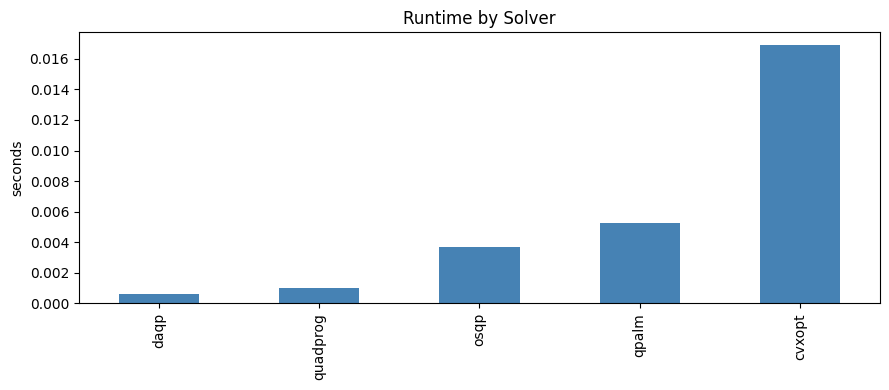

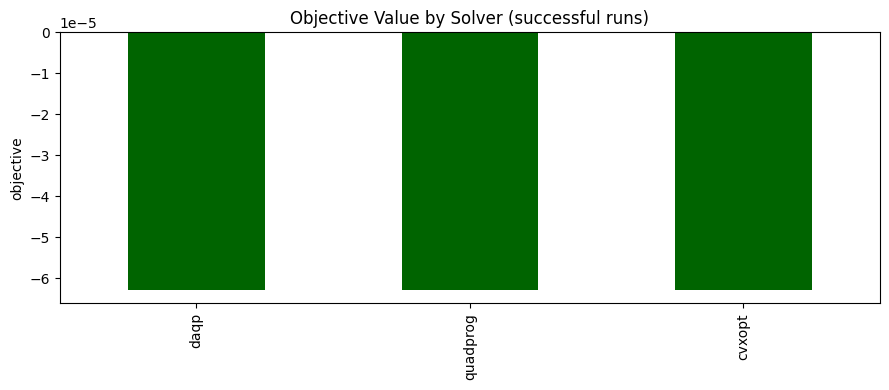

In [8]:
print("Solver comparison table:")
display(results_df)

# Check if we have runtime data to plot
if 'runtime' in results_df.index and not results_df.loc['runtime'].isna().all():
    # Runtime chart
    runtime_s = pd.to_numeric(results_df.loc['runtime'], errors='coerce').dropna().sort_values()
    if not runtime_s.empty:
        plt.figure(figsize=(9, 4))
        runtime_s.plot(kind='bar', color='steelblue')
        plt.title('Runtime by Solver')
        plt.ylabel('seconds')
        plt.tight_layout()
        plt.show()

# Check if any successful solutions exist before plotting the objective
if 'solution_found' in results_df.index:
    ok = results_df.loc['solution_found'] == True
    if ok.any():
        # Objective chart (only successful solvers)
        obj_s = pd.to_numeric(results_df.loc['objective', ok.index[ok]], errors='coerce').dropna().sort_values()
        if not obj_s.empty:
            plt.figure(figsize=(9, 4))
            obj_s.plot(kind='bar', color='darkgreen')
            plt.title('Objective Value by Solver (successful runs)')
            plt.ylabel('objective')
            plt.tight_layout()
            plt.show()
    else:
        print("No successful runs found. Cannot plot objective values.")
else:
    print("'solution_found' row missing. Check the solver loop.")

<Figure size 1400x600 with 0 Axes>

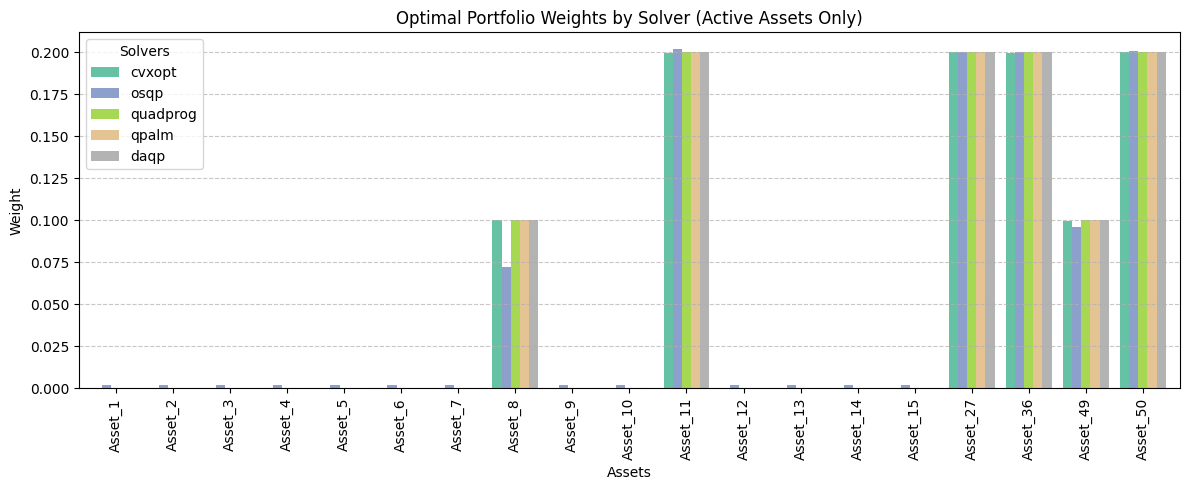

Max absolute difference in weights between cvxopt and osqp: 2.75e-02


In [11]:
# Create a DataFrame of the portfolio weights
if len(weights_dict) > 0:
    weights_df = pd.DataFrame(weights_dict)
    
    # Filter out assets where ALL successful solvers assigned roughly 0% weight
    active_assets = weights_df[weights_df.max(axis=1) > 0.001]
    
    # Plot the grouped bar chart
    plt.figure(figsize=(14, 6))
    active_assets.plot(kind='bar', figsize=(12, 5), width=0.8, colormap='Set2')
    
    plt.title('Optimal Portfolio Weights by Solver (Active Assets Only)')
    plt.ylabel('Weight')
    plt.xlabel('Assets')
    plt.legend(title='Solvers', loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Also print the max difference between the successful solvers to see if they agree
    if len(weights_df.columns) > 1:
        # Compare the first two successful solvers
        s1, s2 = weights_df.columns[0], weights_df.columns[1]
        max_diff = (weights_df[s1] - weights_df[s2]).abs().max()
        print(f"Max absolute difference in weights between {s1} and {s2}: {max_diff:.2e}")
else:
    print("⚠️ No weights to plot because no solvers found a solution.")

## 2. Analytical Solution to Minimum-Variance Problem

(5 points)

- Create a `MinVariance` class that follows the structure of the `MeanVariance` class.
- Implement the `solve` method in `MinVariance` such that if `solver_name = 'analytical'`, the analytical solution is computed and stored within the object (if such a solution exists). If not, call the `solve` method from the parent class.
- Create a `Constraints` object by injecting the same ids as in part 1.b) and add a budget constraint.
- Instantiate a `MinVariance` object by setting `solver_name = 'analytical'` and passing instances of `Constraints` and `Covariance` as arguments.
- Create an `OptimizationData` object that contains an element `return_series`, which consists of the synthetic data generated in part 1.a).
- Solve the optimization problem using the created `MinVariance` object and compare the results to those obtained in part 1.c).


In [12]:
# Define class MinVariance
class MinVariance(Optimization):

    def __init__(self,
                 constraints: Constraints,
                 covariance: Optional[Covariance] = None,
                 **kwargs):
        super().__init__(
            constraints=constraints,
            **kwargs
        )
        self.covariance = Covariance() if covariance is None else covariance

    def check_constraints(self) -> None:
        pass

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        covmat = self.covariance.estimate(X=X, inplace=False)
        mu = np.zeros(X.shape[1])
        
        self.objective = Objective(
            q=mu,
            P=covmat * 2,
        )

    def solve(self) -> None:
        if self.params.get('solver_name') == 'analytical':
            # w = (Sigma^-1 * 1) / (1^T * Sigma^-1 * 1)
            covmat = self.objective.coefficients['P'] / 2
            inv_covmat = np.linalg.inv(covmat)
            ones = np.ones(len(covmat))
            
            w_opt = inv_covmat @ ones / (ones.T @ inv_covmat @ ones)
            
            weights = pd.Series(w_opt, index=self.constraints.ids)
            self.results.update({
                'weights': weights.to_dict(),
                'status': True,
            })
            return None
        else:
            return super().solve()


# Create a constraints object with just a budget constraint
constraints_minvar = Constraints(ids=returns.columns.tolist())
constraints_minvar.add_budget(rhs=1, sense='=')

# Prepare the optimization data (Pass the data directly during initialization!)
opt_data = OptimizationData(return_series=returns)

# Instantiate the MinVariance class
minvar = MinVariance(
    constraints=constraints_minvar,
    covariance=Covariance(method='pearson', check_positive_definite=True),
    solver_name='analytical'
)
minvar.set_objective(opt_data)

# Solve the optimization problem and print the weights
minvar.solve()
w_analytical = pd.Series(minvar.results['weights'])

print("Analytical min-variance weights (first 10):")
print(w_analytical.head(10))
print("\nSum of weights:", round(w_analytical.sum(), 4))

Analytical min-variance weights (first 10):
Asset_1     0.171041
Asset_2    -0.103462
Asset_3    -0.303809
Asset_4     0.378191
Asset_5    -0.007067
Asset_6     0.273829
Asset_7    -0.045121
Asset_8     0.182548
Asset_9     0.383710
Asset_10    0.370293
dtype: float64

Sum of weights: 1.0
